# Code to generate the temperature dependencies used in the manuscript titled ""

### These functions describe the relationship between temperature and identified impacts

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Temperature-dependent fish consumption (Kitchell-style)

In [2]:
def x_function(Q10, Tmax, Topt):
    return (((np.log(Q10) * (Tmax - Topt)) ** 2) / 400.0) * (
        1.0 + (1.0 + (40.0 / (np.log(Q10) * (Tmax - Topt + 2.0))) ** 0.5) ** 2
    )

def kitchell_consumption(Tmax, T, Topt, X):
    T = np.asarray(T, dtype=float)
    out = np.zeros_like(T, dtype=float)
    mask = T <= Tmax
    z = (Tmax - T[mask]) / (Tmax - Topt)
    out[mask] = (z**X) * np.exp(X * (1.0 - z))
    return out

## 2. Conversion Efficiency (Kitchell-like with 0.57 term)

In [3]:
def kitchell_conversion_eff(Tmax, T, Topt, X):
    T = np.asarray(T, dtype=float)
    out = np.zeros_like(T, dtype=float)
    mask = T <= Tmax
    z = (Tmax - T[mask]) / (Tmax - Topt)
    out[mask] = (z**X) * np.exp(X * (0.57 - z))
    return out

## 3. Temperature-dependent Fish Mortality (Arrhenius)


In [4]:
def arrhenius_multiplier(T, T_ref=25.0):
    """
    Dimensionless multiplier relative to T_ref (°C) using:
    exp(10430 * (1/(T_ref+273.15) - 1/(T+273.15))).
    This makes multiplier(T_ref) = 1.
    """
    T = np.asarray(T, dtype=float)
    return np.exp(10430.0 * (1.0/(T_ref + 273.15) - 1.0/(T + 273.15)))

## Plot

In [5]:
# default model params (annual rates)
default_params = {
    "g_H": 0.0065,  # herbivore grazing rate 
    "b": 0.4,       # predator consumption/attack rate
    "e": 0.01,      # conversion efficiency (proportion)
    "m_H": 0.1,     # herbivore mortality 
    "m_P": 0.01,    # predator mortality 
}

# temperature-shape params 
Q10_g, Tmax_g, Topt_g = 2.3, 30.0, 25.0
Q10_b, Tmax_b, Topt_b = 2.3, 30.0, 25.0     # change if want predator to differ
Q10_e, Tmax_e, Topt_e = 1.5, 30.0, 25.0

X_g = x_function(Q10_g, Tmax_g, Topt_g)
X_b = x_function(Q10_b, Tmax_b, Topt_b)
X_e = x_function(Q10_e, Tmax_e, Topt_e)


# Temperature grid
t = np.arange(0, 42.0 + 1e-9, 0.1)

# Multipliers (unitless)
mult_g = kitchell_consumption(Tmax_g, t, Topt_g, X_g)
mult_b = kitchell_consumption(Tmax_b, t, Topt_b, X_b)
mult_e = kitchell_conversion_eff(Tmax_e, t, Topt_e, X_e)

# Temperature-dependent rates/efficiencies to be tested
gH_T = default_params["g_H"] * mult_g           # yr
b_T  = default_params["b"]   * mult_b           # yr
e_T  = default_params["e"]   * mult_e           # proportion

# Mortality: Arrhenius multiplier relative to 25°C applied to annual mortalities
mort_mult = arrhenius_multiplier(t, T_ref=25.0) # unitless
mH_T = default_params["m_H"] * mort_mult        # yr
mP_T = default_params["m_P"] * mort_mult        # yr

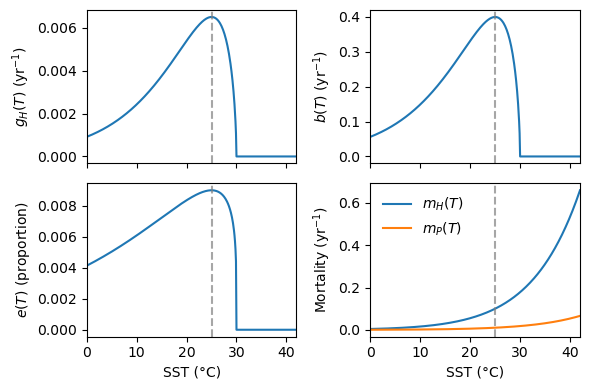

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(6, 4), sharex=True)

ax = axes.flatten()

# Common x-limits
xmin, xmax = t.min(), t.max()

# A: Herbivore grazing
ax[0].plot(t, gH_T)
ax[0].axvline(Topt_g, linestyle='--', color="grey", alpha=0.7)
ax[0].set_ylabel(r"$g_H(T)$ (yr$^{-1}$)")
ax[0].set_xlim(xmin, xmax)

# B: Predator consumption
ax[1].plot(t, b_T)
ax[1].axvline(Topt_b, linestyle='--', color="grey", alpha=0.7)
ax[1].set_ylabel(r"$b(T)$ (yr$^{-1}$)")
ax[1].set_xlim(xmin, xmax)

# C: Conversion efficiency
ax[2].plot(t, e_T)
ax[2].axvline(Topt_e, linestyle='--', color="grey", alpha=0.7)
ax[2].set_xlabel("SST (°C)")
ax[2].set_ylabel(r"$e(T)$ (proportion)")
ax[2].set_xlim(xmin, xmax)

# D: Mortality
ax[3].plot(t, mH_T, label=r"$m_H(T)$")
ax[3].plot(t, mP_T, label=r"$m_P(T)$")
ax[3].axvline(25.0, linestyle='--', color="grey", alpha=0.7)  # reference temperature for mortality
ax[3].set_xlabel("SST (°C)")
ax[3].set_ylabel(r"Mortality (yr$^{-1}$)")
ax[3].set_xlim(xmin, xmax)
ax[3].legend(frameon=False)

plt.tight_layout()
plt.show()